# 1.雇用コスト

* 人員の推移,人を雇用するタイミング
* 費用
* 売上



#### このノートのメインURL

データセット：https://www.kaggle.com/datasets/nagatakengo/kaggriculture-movements-in-the-top-xx

メインnotebook：https://www.kaggle.com/code/nagatakengo/kaggriculture-movements-top-xx

In [1]:
!unzip -qo /content/output_re.zip -d /data

In [2]:
"""
import sys
sys.path.append("/kaggle/input/datasets/nagatakengo/kaggriculture-movements-in-the-top-xx")
sys.path.append("/kaggle/input/datasets/nagatakengo/kaggriculture-movements-in-the-top-xx/Kaggriculture_Movements_in_the_top_xx%")
"""

import pandas as pd
from kaggriculture_df import Kaggriculture_df
from my_plot import sns_line, sns_line_smooth, sns_2_line_smooth, sns_Hist
import ast
from numpy import astype
from kaggle_kaggriculture import convert, xy_plt_2d, xy_plt_2d_all, create_all_hands_feature, new_xy_plt_2d
import matplotlib.pyplot as plt
import seaborn as sns

"""
df_st = (Kaggriculture_df("/kaggle/input/datasets/nagatakengo/kaggriculture-movements-in-the-top-xx/output_re/st_data/strong_rank1_score157577.0_p1.json", 1)).df
df_be = (Kaggriculture_df("/kaggle/input/datasets/nagatakengo/kaggriculture-movements-in-the-top-xx/output_re/be_data/beginner_rank1_score99661.0_p1.json",1)).df
"""

df_st = (Kaggriculture_df("/data/st_data/strong_rank1_score157577.0_p1.json", 1)).df
df_be = (Kaggriculture_df("/data/be_data/beginner_rank1_score99661.0_p1.json",1)).df

In [3]:
df_st.columns

Index(['step', 'day', 'money', 'tiles', 'farmer_x_y', 'hands_n', 'hires_today',
       'unlocked_quadrants', 'private_shed', 'private_seeds', 'market_inv',
       'market_prices', 'farmer_action', 'hands_action', 'market_action',
       'hands_list_1', 'hands_list_2', 'hands_list_3', 'hands_list_4',
       'hands_list_5', 'hands_list_6', 'hands_list_7', 'hands_list_8',
       'hands_list_9', 'hands_list_10', 'hands_list_11', 'hands_list_12',
       'hands_list_13', 'hands_list_14', 'hands_list_15', 'hands_list_16',
       'hands_list_17', 'hands_list_18', 'hands_list_19', 'hands_list_20',
       'hands_action_list_1', 'hands_action_list_2', 'hands_action_list_3',
       'hands_action_list_4', 'hands_action_list_5', 'hands_action_list_6',
       'hands_action_list_7', 'hands_action_list_8', 'hands_action_list_9',
       'hands_action_list_10', 'hands_action_list_11', 'hands_action_list_12',
       'hands_action_list_13', 'hands_action_list_14', 'hands_action_list_15',
       'hands_acti

## 人員の推移,人を雇用するタイミング

In [4]:
def Changespersonnel(df):
    df = df[["step","day","hands_n","money","hires_today"]].copy()
    return df


df_st_day = Changespersonnel(df_st)
df_be_day = Changespersonnel(df_be)

In [5]:
df_st_day

,step,day,hands_n,money,hires_today
0,0,0,0,3000.0,0
1,1,0,5,22.0,5
2,2,0,5,50.0,5
3,3,0,5,22.0,5
4,4,0,5,50.0,5
...,...,...,...,...,...
715,715,29,11,144726.0,11
716,716,29,11,146959.0,11
717,717,29,11,156142.0,11
718,718,29,11,157185.0,11


In [6]:
df_be_day

,step,day,hands_n,money,hires_today
0,0,0,0,3000.0,0
1,1,0,5,22.0,5
2,2,0,5,50.0,5
3,3,0,5,22.0,5
4,4,0,5,50.0,5
...,...,...,...,...,...
715,715,29,11,91747.0,11
716,716,29,11,93457.0,11
717,717,29,11,98093.0,11
718,718,29,11,99229.0,11


上位1%:労働者の人数


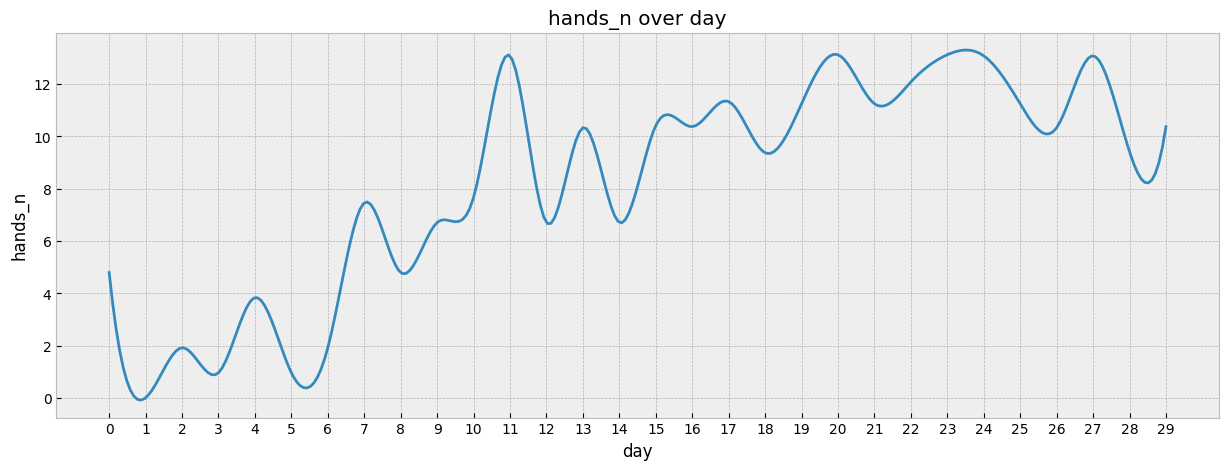

中級者:労働者の人数


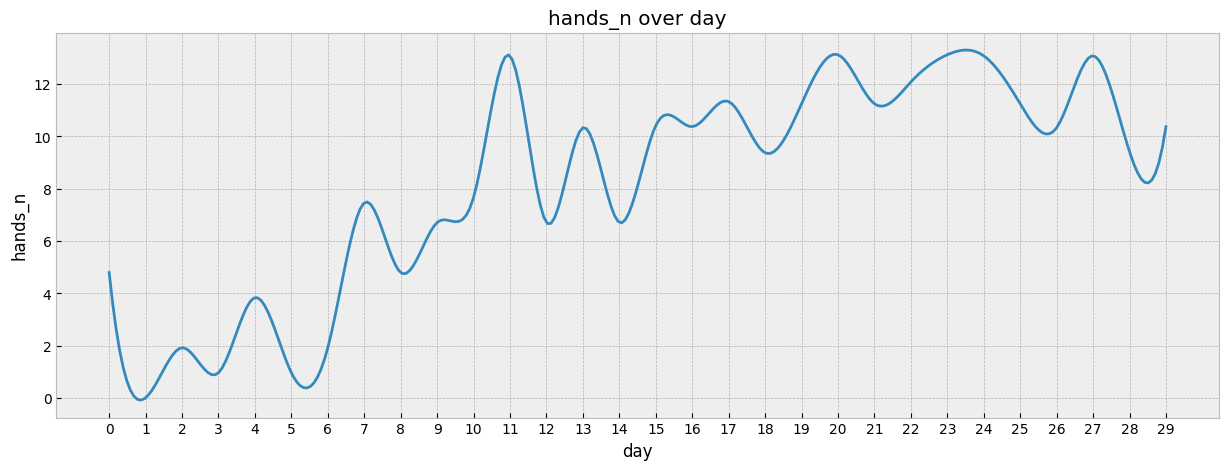

In [7]:
print("上位1%:労働者の人数")
sns_line_smooth(df_st_day, x='day', y="hands_n", figsize=(15, 5), step=1)
print("中級者:労働者の人数")
sns_line_smooth(df_be_day, x='day', y="hands_n", figsize=(15, 5), step=1)

* またしても同じです

In [8]:
print(f"""
test.....

上級者：
{df_st_day["money"].max()}


中級者：
{df_be_day["money"].max()}
""")


test.....

上級者：
157577.0


中級者：
99661.0



## 費用





<br>

|Type|Yield Type|Seed Cost|Base Market Price|Time to First Yield|Time to Max Yield|Subsequent Yields|Max Yield|Action Cost|Max yield / tile / DAY|
|---|---|---|---|---|---|---|---|---|---|
|**Wheat**|One-time|10|25|2 days|4 days|none|6|1|1.5|
|**Carrot**|One-time|20|35|2 days|3 days|none|4|1|1.333|
|**Tomato**|Ongoing|50|60|8 days|NA|every day|4|1|4|
|**Strawberry**|Ongoing|100|120|10 days|NA|every other day|4|1|2|
|**Melon**|One-time|80|250|10 days|12 days|none|6|1|.5|
|**Goose/Egg**|Ongoing|300|50|4 days|NA|every day|4|1 + 1 (build coop)|2|
|**Cow/Milk**|Ongoing|400|160|8 days|NA|every two days|6|1 + 1 (build pasture)|1|
|**Sheep/Wool**|Ongoing|500|200|6 days|NA|every three days|6|1 + 1 (build pasture)|.67|
|**Fertilizer**|NA|100|X||X|X||1|

👇和訳

| タイプ        | 収量タイプ | 種子のコスト | 基本市場価格 | 初回収穫までの時間 | 最大収量を得るまでの時間 | その後の収益 | 最大収量 | アクションコスト        | タイル1枚あたりの最大収穫量／日 |
| ---------- | ----- | ------ | ------ | --------- | ------------ | ------ | ---- | --------------- | ---------------- |
| **小麦**     | 一度    | 10     | 25     | 2日間       | 4日間          | なし     | 6    | 1               | 1.5              |
| **ニンジン**   | 一度    | 20     | 35     | 2日間       | 3日間          | なし     | 4    | 1               | 1.333            |
| **トマト**    | 継続中   | 50     | 60     | 8日間       | 該当なし         | 毎日     | 4    | 1               | 4                |
| **いちご**    | 継続中   | 100    | 120    | 10日間      | 該当なし         | 隔日     | 4    | 1               | 2                |
| **メロン**    | 一度    | 80     | 250    | 10日間      | 12日間         | なし     | 6    | 1               | 0.5              |
| **ガチョウの卵** | 継続中   | 300    | 50     | 4日間       | 該当なし         | 毎日     | 4    | 1 + 1 (協力プレイ構築) | 2                |
| **牛/牛乳**   | 継続中   | 400    | 160    | 8日間       | 該当なし         | 2日ごとに  | 6    | 1 + 1 (牧草地を作る)  | 1                |
| **羊毛**     | 継続中   | 500    | 200    | 6日間       | 該当なし         | 3日ごとに  | 6    | 1 + 1 (牧草地を作る)  | 0.67             |
| **肥料**     | 該当なし  | 100    | X      |           | X            | X      |      | 1               |                  |

```
（種子の購入）
["BUY_SEED", crop, n]
crop:
WHEAT=10
CARROT=20
TOMATO=50
STRAWBERRY=100
MELON=80

```

```
（製品の購入）
["BUY_PRODUCT", item, n]
item:
WHEAT=変動
FERTILIZER=変動

```

```
（動物の購入）
["BUY_ANIMAL", animal, n]
animal:
GOOSE=300
COW=400
SHEEP=500
```

```
（アイテムの販売）
["SELL", item, n]
item:
WHEAT=変動
CARROT=変動
TOMATO=変動
STRAWBERRY=変動
MELON=変動
EGG=変動
MILK=変動
WOOL=変動
```

```
（農作業員の雇用）
["HIRE"]
「同じ日に何人目を雇うか」によって変動
計算式: farmHandCostMult * fib(n) （n はその日にすでに雇用した人数）
```
```
（土地の購入）
["BUY_LAND"]
1つ目の追加区画 (NEなど): 1,000ドル
2つ目の追加区画: 2,000ドル
3つ目の追加区画: 4,000ドル
```




In [9]:
def cost(df):
    df = df[["step","day","money", "market_action","market_prices"]].copy()

    prices_df = df["market_prices"].apply(pd.Series)
    prices_df = prices_df.rename(columns=lambda x: f"market_prices_{x}")
    df = pd.concat([df, prices_df], axis=1)

    seed_prices = {"WHEAT": 10, "CARROT": 20, "TOMATO": 50, "STRAWBERRY": 100, "MELON": 80}
    animal_prices = {"GOOSE": 300, "COW": 400, "SHEEP": 500}
    land_prices = [1000, 2000, 4000]


    def get_fib(n):
        if n <= 1: return 1
        a, b = 1, 1
        for _ in range(2, n + 1):
            a, b = b, a + b
        return b

    costs = []


    current_day = -1
    hires_today = 0
    lands_bought = 0


    for idx, row in df.iterrows():

        if row["day"] != current_day:
            hires_today = 0
            current_day = row["day"]

        total_cost = 0
        actions = row["market_action"]

        if isinstance(actions, list):
            if len(actions) > 0 and isinstance(actions[0], str):
                actions = [actions]

            for action in actions:
                if not isinstance(action, list) or len(action) == 0:
                    continue

                act_type = action[0]

                if act_type == "BUY_SEED" and len(action) == 3:
                    crop = action[1]
                    n = action[2]
                    if crop in seed_prices:
                        total_cost += seed_prices[crop] * n

                elif act_type == "BUY_PRODUCT" and len(action) == 3:
                    item = action[1]
                    n = action[2]
                    price_col = f"market_prices_{item}"
                    if price_col in row:
                        total_cost += row[price_col] * n

                elif act_type == "BUY_ANIMAL" and len(action) == 3:
                    animal = action[1]
                    n = action[2]
                    if animal in animal_prices:
                        total_cost += animal_prices[animal] * n

                elif act_type == "SELL" and len(action) == 3:
                    item = action[1]
                    n = action[2]
                    price_col = f"market_prices_{item}"
                    if price_col in row:

                        total_cost -= row[price_col] * n

                elif act_type == "HIRE":

                    total_cost += get_fib(hires_today)
                    hires_today += 1

                elif act_type == "BUY_LAND":
                    if lands_bought < len(land_prices):
                        total_cost += land_prices[lands_bought]
                        lands_bought += 1

        costs.append(total_cost)

    df["market_action_cost"] = costs
    return df
df_st_cost = cost(df_st)
df_be_cost = cost(df_be)

In [10]:
df_st_cost

,step,day,money,market_action,market_prices,market_prices_CARROT,market_prices_EGG,market_prices_FERTILIZER,market_prices_MELON,market_prices_MILK,market_prices_STRAWBERRY,market_prices_TOMATO,market_prices_WHEAT,market_prices_WOOL,market_action_cost
0,0,0,3000.0,[],"{'CARROT': 35, 'EGG': 50, 'FERTILIZER': 100, '...",35,50,100,250,160,120,60,25,200,0
1,1,0,22.0,"[[HIRE], [HIRE], [HIRE], [HIRE], [HIRE], [BUY_...","{'CARROT': 36, 'EGG': 50, 'FERTILIZER': 100, '...",36,50,100,256,169,128,60,28,206,2982
2,2,0,50.0,"[[SELL, WHEAT, 1]]","{'CARROT': 36, 'EGG': 50, 'FERTILIZER': 100, '...",36,50,100,256,169,128,60,28,206,-28
3,3,0,22.0,"[[BUY_PRODUCT, WHEAT, 1]]","{'CARROT': 36, 'EGG': 50, 'FERTILIZER': 100, '...",36,50,100,256,169,128,60,28,206,28
4,4,0,50.0,"[[SELL, WHEAT, 1]]","{'CARROT': 36, 'EGG': 50, 'FERTILIZER': 100, '...",36,50,100,256,169,128,60,28,206,-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,715,29,144726.0,"[[SELL, WOOL, 4], [SELL, WHEAT, 8]]","{'CARROT': 40, 'EGG': 52, 'FERTILIZER': 16, 'M...",40,52,16,25,288,229,74,45,167,-1028
716,716,29,146959.0,"[[SELL, WOOL, 4], [SELL, MILK, 3], [SELL, WHEA...","{'CARROT': 40, 'EGG': 52, 'FERTILIZER': 16, 'M...",40,52,16,25,286,220,74,45,141,-2142
717,717,29,156142.0,"[[SELL, WOOL, 10], [SELL, WHEAT, 18], [SELL, M...","{'CARROT': 40, 'EGG': 52, 'FERTILIZER': 16, 'M...",40,52,16,25,284,214,74,44,55,-8680
718,718,29,157185.0,"[[SELL, MILK, 2], [SELL, WHEAT, 11]]","{'CARROT': 40, 'EGG': 52, 'FERTILIZER': 16, 'M...",40,52,16,25,282,214,74,43,55,-1037


In [11]:
df_be_cost

,step,day,money,market_action,market_prices,market_prices_CARROT,market_prices_EGG,market_prices_FERTILIZER,market_prices_MELON,market_prices_MILK,market_prices_STRAWBERRY,market_prices_TOMATO,market_prices_WHEAT,market_prices_WOOL,market_action_cost
0,0,0,3000.0,[],"{'CARROT': 35, 'EGG': 50, 'FERTILIZER': 100, '...",35,50,100,250,160,120,60,25,200,0
1,1,0,22.0,"[[HIRE], [HIRE], [HIRE], [HIRE], [HIRE], [BUY_...","{'CARROT': 36, 'EGG': 50, 'FERTILIZER': 100, '...",36,50,100,256,169,128,60,28,206,2982
2,2,0,50.0,"[[SELL, WHEAT, 1]]","{'CARROT': 36, 'EGG': 50, 'FERTILIZER': 100, '...",36,50,100,256,169,128,60,28,206,-28
3,3,0,22.0,"[[BUY_PRODUCT, WHEAT, 1]]","{'CARROT': 36, 'EGG': 50, 'FERTILIZER': 100, '...",36,50,100,256,169,128,60,28,206,28
4,4,0,50.0,"[[SELL, WHEAT, 1]]","{'CARROT': 36, 'EGG': 50, 'FERTILIZER': 100, '...",36,50,100,256,169,128,60,28,206,-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,715,29,91747.0,"[[SELL, WOOL, 4], [SELL, WHEAT, 8]]","{'CARROT': 41, 'EGG': 52, 'FERTILIZER': 16, 'M...",41,52,16,25,303,89,128,50,1,-404
716,716,29,93457.0,"[[SELL, MILK, 3], [SELL, WOOL, 4], [SELL, WHEA...","{'CARROT': 41, 'EGG': 52, 'FERTILIZER': 16, 'M...",41,52,16,25,301,89,128,50,1,-1707
717,717,29,98093.0,"[[SELL, STRAWBERRY, 25], [SELL, WHEAT, 18], [S...","{'CARROT': 41, 'EGG': 52, 'FERTILIZER': 16, 'M...",41,52,16,25,299,9,128,49,1,-3210
718,718,29,99229.0,"[[SELL, MILK, 2], [SELL, WHEAT, 11]]","{'CARROT': 41, 'EGG': 52, 'FERTILIZER': 16, 'M...",41,52,16,25,298,9,128,48,1,-1124


## コスト

* うまくプロット出来ませんでしたがmarket_action
かかるコストを加算し、により、行動した結果をグラフにしました（ちょっとわかりにくいですが）
かかったコストは正の値です。

* 負の値はmarket_actionにて起こした行動によって得られた売上です。そうです、これは利益ではありません

In [12]:
df_st_cost["market_action_cost"].min()

-9058

In [13]:
df_st_cost["market_action_cost"].max()

4266

#### この表は上位プレーヤーのキャッシュフローの一部です。


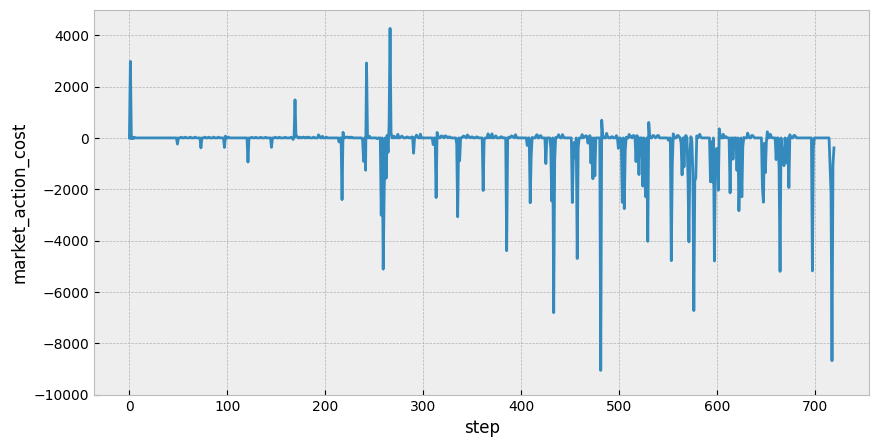

In [14]:
def cost_plot(df,col,y):
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=df, x=col, y=y)
    plt.ylim(-10000, 5000)
    plt.grid(True)
    plt.show()

cost_plot(df_st_cost,"step", 'market_action_cost')

#### この表は中級の位置に値するプレーヤーのキャッシュフローの一部です

* ここでやっと同じデータではないと確信しました。

* オープンソースのロジックを使用し、動き制御は大前提にあり、この先の攻防が醍醐味のようです。

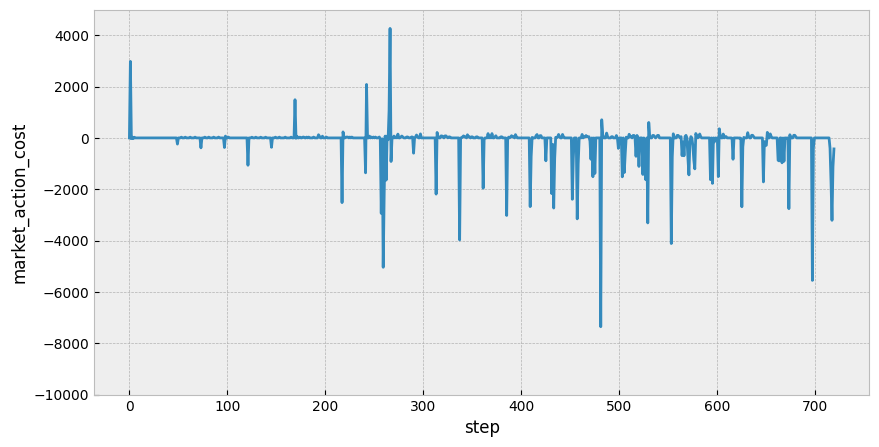

In [15]:
cost_plot(df_be_cost,"step", 'market_action_cost')

# 2.物価


* 次は各商品の値段を可視化していきます<br>

```py
{'CARROT': xx,
 'EGG': xx,
 'FERTILIZER': xx,
 'MELON': xx,
 'MILK': xx,
 'STRAWBERRY': xx,
 'TOMATO': xx,
 'WHEAT': xx,
 'WOOL': xx}
```




In [16]:
df_st_cost['market_prices_CARROT'].min(),df_st_cost['market_prices_CARROT'].max()

(35, 40)

## 人参,CARROT

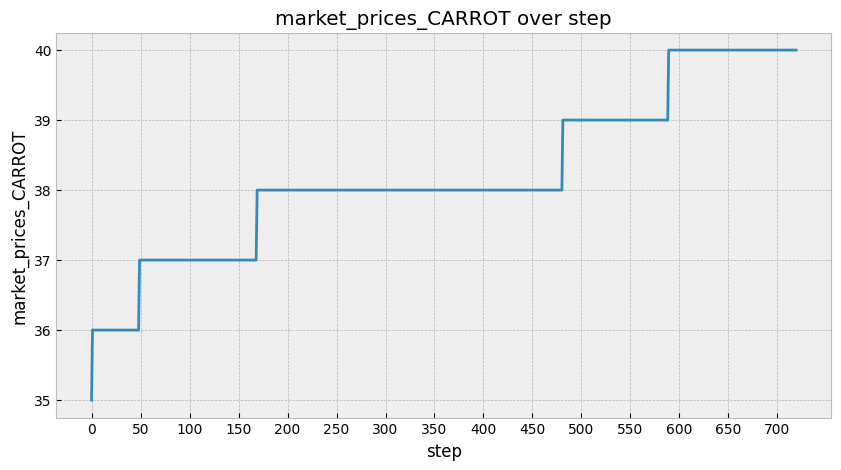

In [17]:
sns_line(df_st_cost, x='step', y="market_prices_CARROT", figsize=(10,5), step=50,)

## 卵,EGG

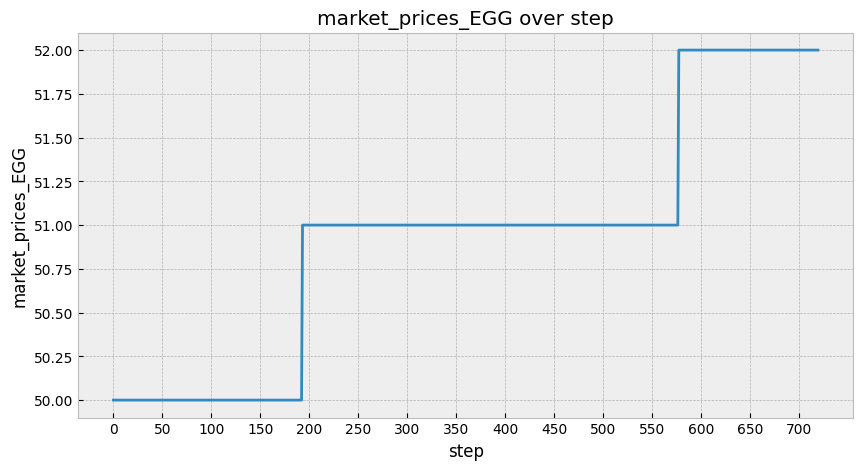

In [18]:
sns_line(df_st_cost, x='step', y="market_prices_EGG", figsize=(10,5), step=50,)

## 肥料,FERTILIZER

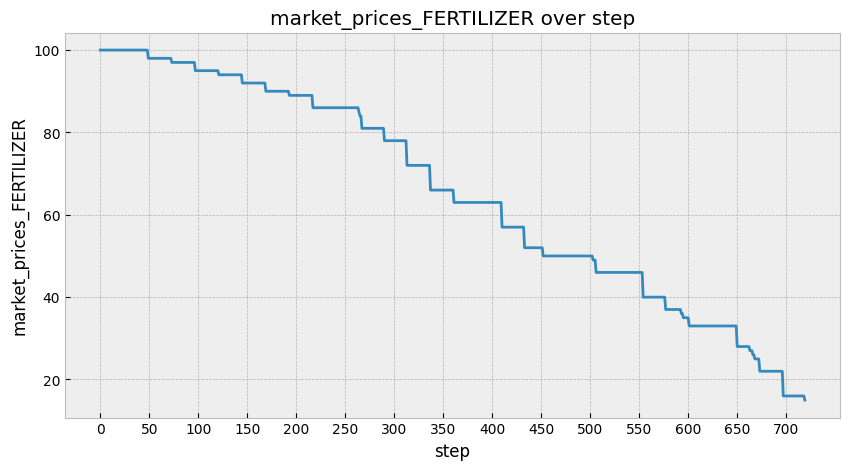

In [19]:
sns_line(df_st_cost, x='step', y="market_prices_FERTILIZER", figsize=(10,5), step=50,)

## メロン,MELON

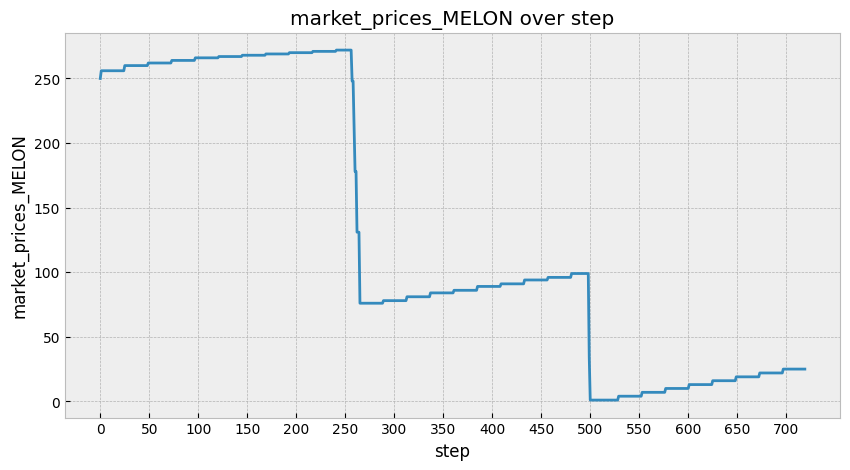

In [20]:
sns_line(df_st_cost, x='step', y="market_prices_MELON", figsize=(10,5), step=50,)

ミルク,MILK

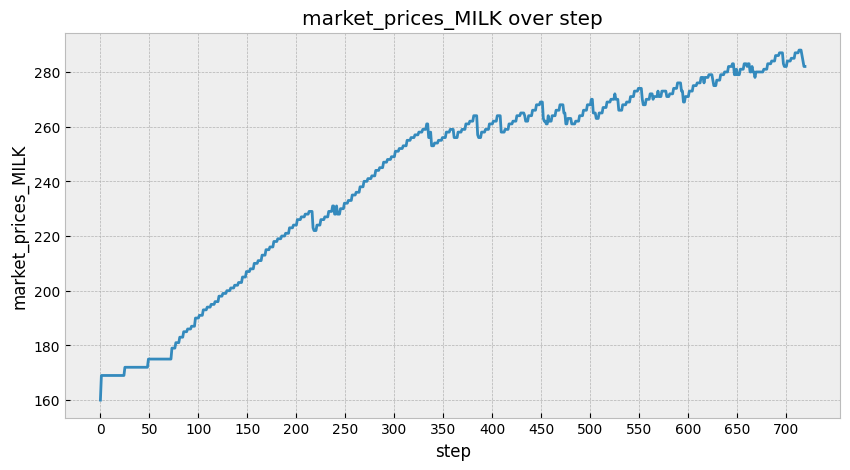

In [21]:
sns_line(df_st_cost, x='step', y="market_prices_MILK", figsize=(10,5), step=50,)

## いちご,STRAWBERRY

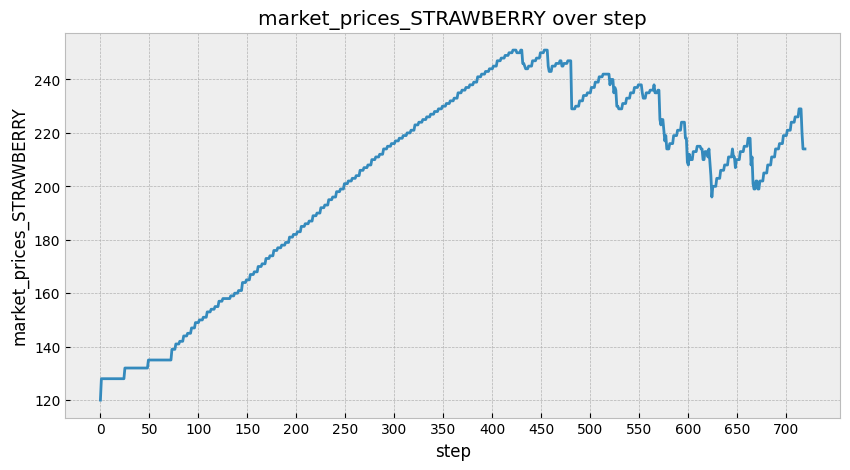

In [22]:
sns_line(df_st_cost, x='step', y="market_prices_STRAWBERRY", figsize=(10,5), step=50,)

## トマト,TOMATO





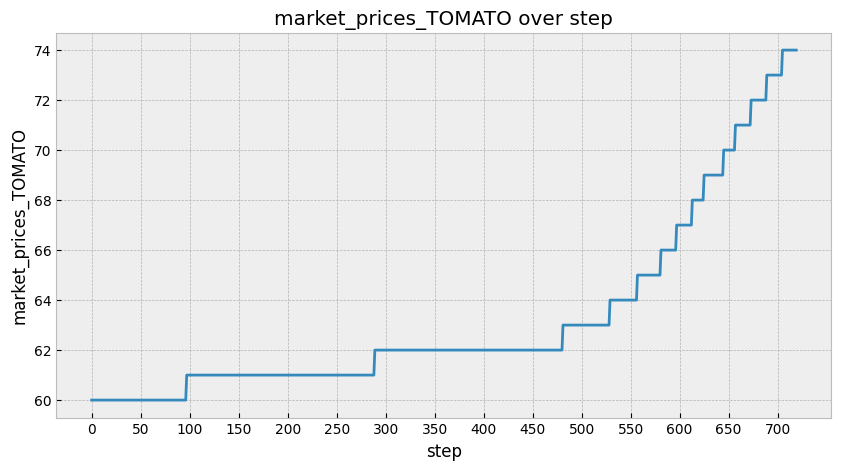

In [23]:
sns_line(df_st_cost, x='step', y="market_prices_TOMATO", figsize=(10,5), step=50,)

## 小麦,WHEAT

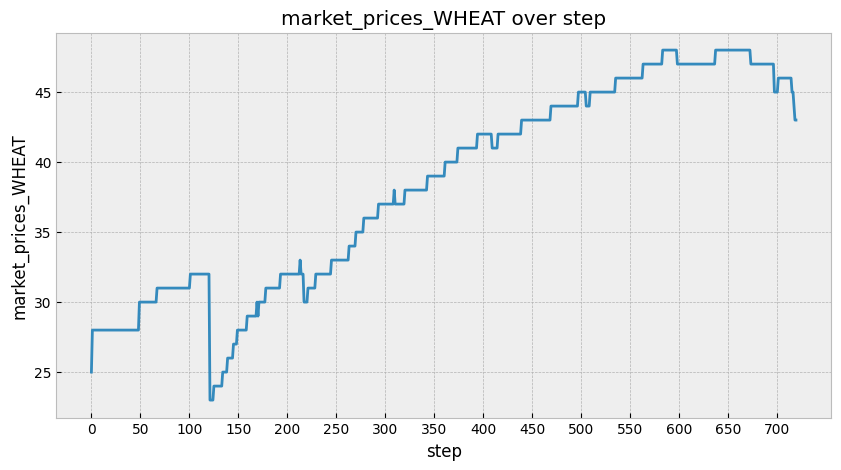

In [24]:
sns_line(df_st_cost, x='step', y="market_prices_WHEAT", figsize=(10,5), step=50,)

## 羊の毛皮,WOOL

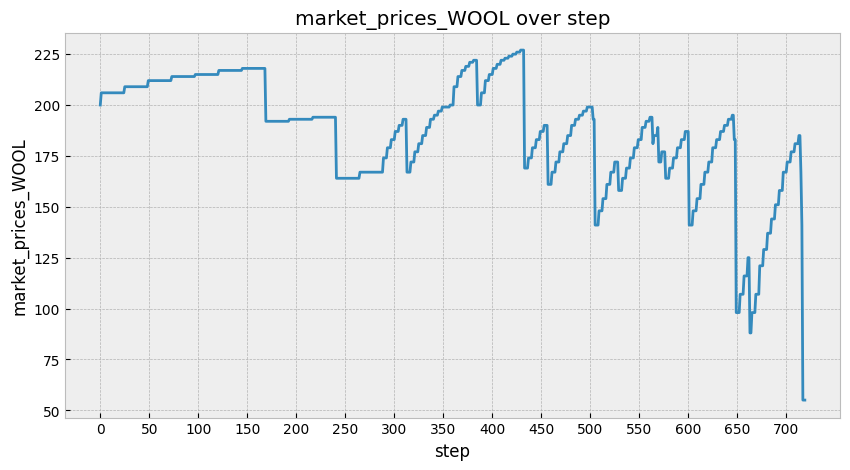

In [25]:
sns_line(df_st_cost, x='step', y="market_prices_WOOL", figsize=(10,5), step=50,)

# 3.所持金の増減

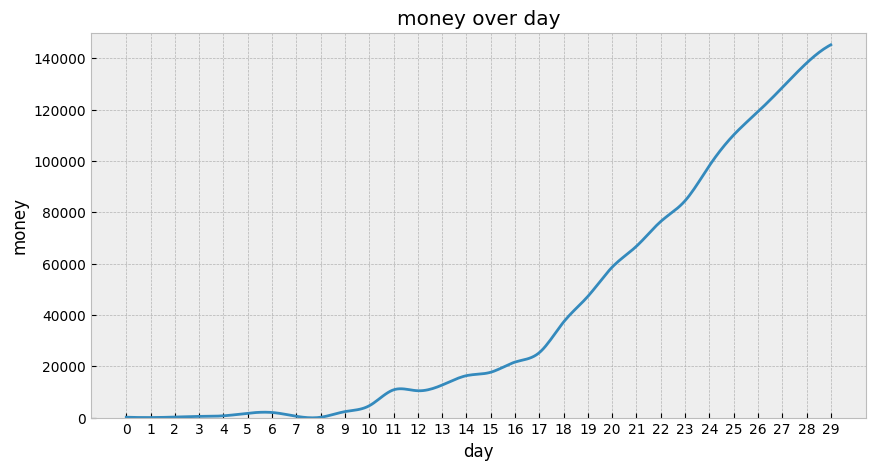

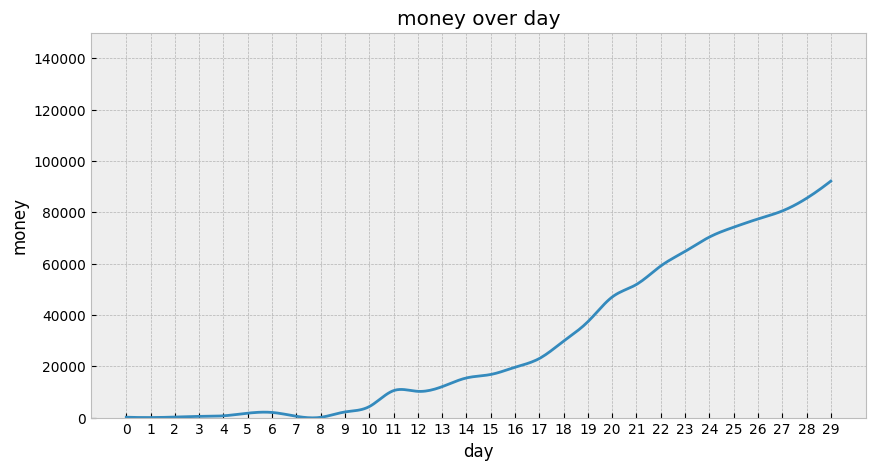

In [26]:
sns_line_smooth(df_st_cost, x='day', y="money", figsize=(10, 5), step=1,ylim=(0, 150000))
sns_line_smooth(df_be_cost, x='day', y="money", figsize=(10, 5), step=1,ylim=(0, 150000))

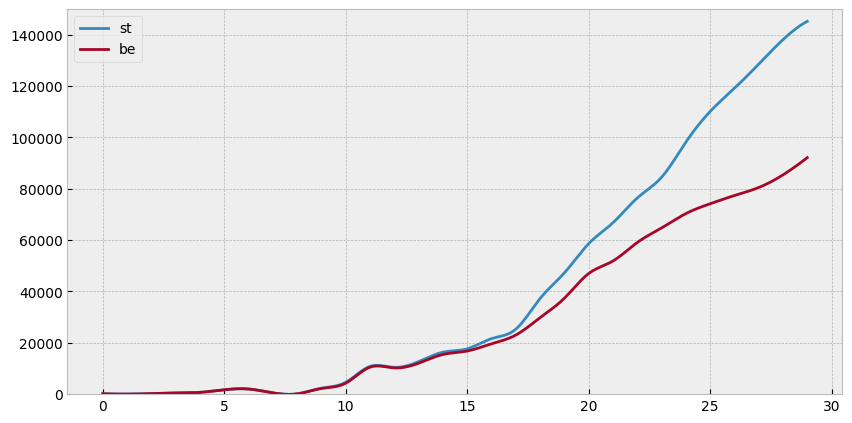

In [27]:
plt.figure(figsize=(10, 5))

sns_2_line_smooth(df_st_cost, x='day', y="money", label="st", step=1)
sns_2_line_smooth(df_be_cost, x='day', y="money", label="be", step=1)

plt.ylim(0, 150000)
plt.legend()
plt.show()

## 章の終わりに

* 物価の推移がこのゲームの勝敗を大きく決めそうだなと思った。